# Appendix: mixtures of multichannel hidden Markov models

Section 4 extends every clustering result to hidden Markov models with multichannel
observations, and is the only part of the paper with no figure. This notebook gives it one,
by running the whole numerical section again on that mechanism and asking whether the
conclusions survive.

**What changes.** A component is now a homogeneous HMM: a latent chain on four hidden
states drives five conditionally independent channels of five letters each. A sequence is an
$(n, 5)$ array rather than an $(n,)$ one, and the dissimilarity is the multichannel OM of
Definition 4.1, $c_{\mathrm{sub}} = \sum_c c_{\mathrm{sub}}^{(c)}$ and
$\delta = \sum_c \delta^{(c)}$, with constant per-channel costs. That aggregation gives
$M^{\mathrm{mc}} = 10$ and $\delta^{\mathrm{mc}} = 5$ against 2 and 1 in the univariate
case, and Assumption 1 holds — checked channel by channel, since the product alphabet has
$5^5 = 3125$ letters and the triangle inequality on it is a 227 GiB table.

The costs are fixed in advance rather than estimated from the data, unlike the TRATE path.
$\Gamma^{(n)}$ is estimated on an independent sample, and a cost scheme derived from that
sample would make the dissimilarity depend on which sequences happened to be drawn.

**What does not change.** Everything downstream of the dissimilarity matrix. The same
estimator of $\Gamma^{(n)}$, the same simultaneous intervals, the same four clustering
algorithms, the same rules for $K$ — none of them knows which mechanism produced the matrix
it reads.

**The grid axis.** The single knob $\alpha$ ties the Dirichlet concentrations of the
initial law, transitions, and emissions. Small values give sharply peaked laws and
components that are easy to tell apart.

In [1]:
%load_ext autoreload
%autoreload 2

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from clustering import (asw_select_k, exact_recovery, profile_distances,
                        profile_graph_k, profile_heights,
                        safeguard_threshold as theorem_3_8_threshold)
from experiments import (ALGORITHMS, ResultsWriter, draw_hmm_mixture,
                         estimate_gamma_paths, eta_rows, multichannel_om,
                         save_mixture, score_dataset, stream, wilson_interval)
from figures import DIVERGING_CMAP, PAPER_STYLE, heatmap, save

## Setup

Everything reported below is computed in this notebook: mixtures, independent estimates
of $\Gamma^{(n)}$, dissimilarity matrices, clustering, rules for $K$, and horizon paths.
As in `difficulty_grid`, `SOURCE = "compute"` overwrites dedicated run tables and never
reuses rows from an earlier run. `SOURCE = "paper"` is the explicit opt-out for loading
the archived tables. The full settings take several hours; reduce the knobs below for a
quick end-to-end run.

In [ ]:
# --- the knobs -------------------------------------------------------------
SOURCE = "compute"       # "compute": rebuild everything; "paper": archived CSVs
N = 800                    # sequences per clustering dataset
R_MIX = 30                 # mixtures per (alpha, K) cell
ALPHAS = [1.0, 2.0, 3.0, 5.0, 10.0, 30.0]
KS = list(range(2, 11))
HORIZONS = [1000]
HORIZON = 1000
N_GAMMA = 60
LEVEL = 0.95
SEED = 20260901
PAM_RESTARTS = 1
K_MAX_ASW = 12
HMM_STATES, HMM_VARS, HMM_CATEGORIES = 4, 5, [5] * 5
ALGOS = ["average", "pam"]
ALGOS_ALL = list(ALGORITHMS)
RULES = ["threshold", "asw-pam"]
PATH_ALGOS = ["single", "average", "pam"]
PATH_ALPHA, PATH_K = 3.0, 4
PATH_MIXTURES, PATH_DATASETS = 6, 20
PATH_HORIZONS = [10]


RESULTS = Path("results")
FIGURES = Path("Figures/HMM")
FIGURES.mkdir(parents=True, exist_ok=True)
OUT = {kind: RESULTS / f"hmm_notebook_{kind}.csv"
       for kind in ("cluster", "eta", "khat")}
OUT_PATH = RESULTS / "hmm_notebook_path.csv"
PAPER = {"cluster": RESULTS / "recovery_cluster_hmm.csv",
         "eta": RESULTS / "recovery_eta_hmm.csv",
         "khat": RESULTS / "khat_grid_hmm.csv"}
PAPER_PATH = RESULTS / "path_cluster_hmm.csv"

FIELDS = {
    "cluster": ["alpha", "K", "d", "mixture_id", "n", "N",
                "cost_scheme", "algorithm", "dataset_id", "exact_recovery",
                "ari", "k_hat", "k_correct", "exact_recovery_at_k_hat",
                "pam_one_swap_certified", "pam_hit_cap", "mixture_key"],
    "eta": ["alpha", "K", "mixture_id", "n", "cost_scheme", "eta_hat",
            "eta_ci_low", "eta_ci_high", "separation_status", "n_pairs",
            "level", "mixture_key"],
    "khat": ["alpha", "K", "mixture_id", "dataset_id", "n", "N", "d",
             "cost_scheme", "rule", "threshold", "k_hat", "k_correct",
             "exact_recovery", "mixture_key"],
}
PATH_FIELDS = FIELDS["cluster"]


def build_problem(K, alpha, mixture_id):
    om = multichannel_om("constant", HMM_CATEGORIES, sub=2.0, indel=1.0)
    mixture = draw_hmm_mixture(K, HMM_STATES, HMM_VARS, HMM_CATEGORIES,
                               mixture_id, SEED, alpha=alpha)
    return mixture, om


def evaluate_rules(D, rho, heights, truth, N, n, M):
    out = []
    threshold = theorem_3_8_threshold(rho, n, heights)
    k_hat, labels = profile_graph_k(None, rho=rho, threshold=threshold,
                                    return_labels=True)
    out.append(("threshold", threshold, k_hat, labels))
    k_hat, labels = asw_select_k(D, k_max=K_MAX_ASW, method="pam",
                                  pam_restarts=PAM_RESTARTS, return_labels=True)
    out.append(("asw-pam", "", k_hat, labels))
    return out


def sweep_unit(alpha, K, m):
    mixture, om = build_problem(K, alpha, m)
    save_mixture(mixture, RESULTS / "mixtures" / "hmm")
    estimate = estimate_gamma_paths(
        mixture, om, HORIZONS, N_GAMMA,
        stream(SEED, "hmm", "grid-gamma", alpha, K, m))
    geometry = eta_rows(mixture, om, estimate, level=LEVEL)
    rng = stream(SEED, "hmm", "grid-data", alpha, K, m)
    X, truth = mixture.sample_dataset(N, max(HORIZONS), rng)
    matrices = om.matrices(X, HORIZONS)
    cluster = score_dataset(mixture, om, matrices, truth, N, HORIZONS, rng, 0,
                            algorithms=ALGORITHMS, pam_restarts=PAM_RESTARTS)
    selection = []
    g = HORIZONS.index(HORIZON)
    D = matrices[g]
    rho, heights = profile_distances(D), None
    heights = profile_heights(rho)
    for rule, threshold, k_hat, labels in evaluate_rules(
            D, rho, heights, truth, N, HORIZON, om.M):
        selection.append({"alpha": alpha, "K": K, "mixture_id": m,
                          "dataset_id": 0, "n": HORIZON, "N": N,
                          "d": mixture.d, "cost_scheme": om.name, "rule": rule,
                          "threshold": threshold, "k_hat": int(k_hat),
                          "k_correct": int(k_hat == K),
                          "exact_recovery": int(exact_recovery(labels, truth)),
                          "mixture_key": mixture.key})
    return geometry, cluster, selection


def compute_grid():
    for path in OUT.values():
        path.unlink(missing_ok=True)
    writers = {kind: ResultsWriter(OUT[kind], FIELDS[kind]) for kind in FIELDS}
    units = [(a, K, m) for a in ALPHAS for K in KS for m in range(R_MIX)]
    start = time.perf_counter()
    try:
        for done, (alpha, K, m) in enumerate(units, 1):
            geometry, cluster, selection = sweep_unit(alpha, K, m)
            for kind, rows in (("eta", geometry), ("cluster", cluster),
                               ("khat", selection)):
                writers[kind].write([{k: row.get(k, "") for k in FIELDS[kind]}
                                     for row in rows])
            if done % 10 == 0 or done == len(units):
                elapsed = time.perf_counter() - start
                left = (len(units) - done) * elapsed / done
                print(f"HMM: {done}/{len(units)}, ~{left/60:.1f} min left",
                      flush=True)
    finally:
        for writer in writers.values():
            writer.close()


def compute_paths():
    OUT_PATH.unlink(missing_ok=True)
    writer = ResultsWriter(OUT_PATH, PATH_FIELDS)
    try:
        for m in range(PATH_MIXTURES):
            mixture, om = build_problem(PATH_K, PATH_ALPHA, m)
            save_mixture(mixture, RESULTS / "mixtures" / "hmm-path")
            for r in range(PATH_DATASETS):
                rng = stream(SEED, "hmm", "path-data", PATH_ALPHA, PATH_K, m, r)
                X, truth = mixture.sample_dataset(N, max(PATH_HORIZONS), rng)
                matrices = om.matrices(X, PATH_HORIZONS)
                rows = score_dataset(mixture, om, matrices, truth, N, PATH_HORIZONS,
                                     rng, r, algorithms=PATH_ALGOS,
                                     pam_restarts=PAM_RESTARTS)
                writer.write([{k: row.get(k, "") for k in PATH_FIELDS} for row in rows])
            print(f"HMM paths: mixture {m + 1}/{PATH_MIXTURES}", flush=True)
    finally:
        writer.close()


if SOURCE == "compute":
    print(f"computing HMMs: {len(ALPHAS)} x {len(KS)} x {R_MIX} units")
    compute_grid()
    compute_paths()


def load(kind):
    path = OUT[kind] if SOURCE == "compute" else PAPER[kind]
    return pd.read_csv(path)


hmm_cluster, hmm_eta, hmm_khat = (load(kind)
                                      for kind in ("cluster", "eta", "khat"))
hmm_path = pd.read_csv(OUT_PATH if SOURCE == "compute" else PAPER_PATH)

def at_horizon(df):
    return df[df.n == HORIZON]

hmm_cluster = at_horizon(hmm_cluster)
hmm_eta = at_horizon(hmm_eta)
hmm_khat = at_horizon(hmm_khat)
ALPHAS_PRESENT = ALPHAS
print(f"grids drawn from this run on alpha in {ALPHAS_PRESENT}")

computing HMMs: 7 x 9 x 20 units
HMM: 10/1260, ~15.7 min left
HMM: 20/1260, ~15.1 min left
HMM: 30/1260, ~15.2 min left
HMM: 40/1260, ~13.8 min left
HMM: 50/1260, ~13.8 min left
HMM: 60/1260, ~13.4 min left
HMM: 70/1260, ~12.9 min left
HMM: 80/1260, ~13.4 min left
HMM: 90/1260, ~12.8 min left
HMM: 100/1260, ~12.1 min left
HMM: 110/1260, ~11.6 min left
HMM: 120/1260, ~11.5 min left
HMM: 130/1260, ~11.3 min left
HMM: 140/1260, ~11.4 min left
HMM: 150/1260, ~11.3 min left
HMM: 160/1260, ~11.7 min left
HMM: 170/1260, ~11.8 min left
HMM: 180/1260, ~11.8 min left
HMM: 190/1260, ~11.8 min left
HMM: 200/1260, ~11.8 min left
HMM: 210/1260, ~11.8 min left
HMM: 220/1260, ~11.7 min left
HMM: 230/1260, ~11.6 min left
HMM: 240/1260, ~11.3 min left
HMM: 250/1260, ~11.0 min left
HMM: 260/1260, ~10.8 min left
HMM: 270/1260, ~10.7 min left
HMM: 280/1260, ~10.5 min left
HMM: 290/1260, ~10.5 min left
HMM: 300/1260, ~10.4 min left
HMM: 310/1260, ~10.6 min left
HMM: 320/1260, ~10.5 min left
HMM: 330/1260, ~

## Reading a cell

In [3]:
def grid(df, value, agg="mean"):
    table = df.pivot_table(index="alpha", columns="K", values=value, aggfunc=agg)
    return table.reindex(index=ALPHAS_PRESENT, columns=KS).to_numpy(dtype=float)


def verdict_balance(eta):
    """Pr(separated) - Pr(nonseparated): +1 all separated, -1 all not, 0 no verdict."""
    e = eta.assign(sep=(eta.separation_status == "separated").astype(int),
                   non=(eta.separation_status == "nonseparated").astype(int))
    return grid(e, "sep") - grid(e, "non"), grid(e, "sep"), grid(e, "eta_hat", agg="median")

## Plausibility of the separation condition

For the HMM grid, blue where $\eta_n > 0$ is established at 95% simultaneous
confidence, red where $\eta_n < 0$ is, pale where the interval cannot decide.

figure written to Figures\HMM\separation_hmm.pdf


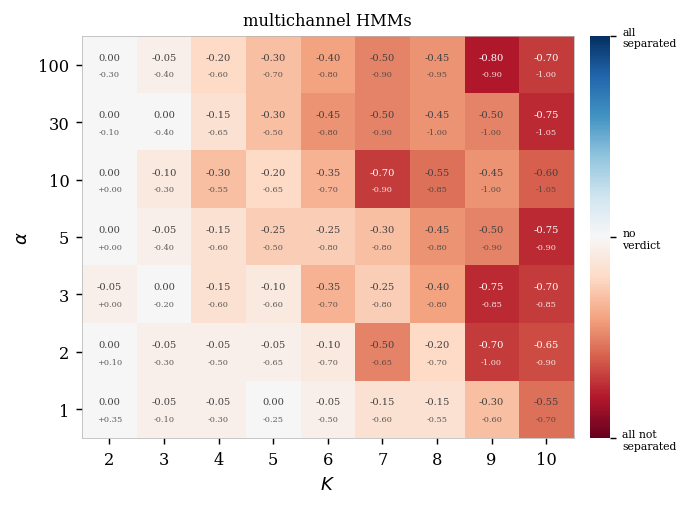

In [4]:
balance, _, margin = verdict_balance(hmm_eta)
with plt.rc_context(PAPER_STYLE):
    fig, ax = plt.subplots(figsize=(5.4, 4.0))
    im = heatmap(ax, balance, ALPHAS_PRESENT, KS, "multichannel HMMs",
                 annot=margin, cmap=DIVERGING_CMAP, vmin=-1.0, vmax=1.0)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03, ticks=[-1, 0, 1])
    cb.ax.set_yticklabels(["all not\nseparated", "no\nverdict", "all\nseparated"], fontsize=6)
    cb.outline.set_visible(False)
    fig.tight_layout()
    save(fig, FIGURES, "separation_hmm")
    plt.show()

## Recovery at known $K$

Average linkage and PAM, on the same grid.

figure written to Figures\HMM\recovery_hmm.pdf


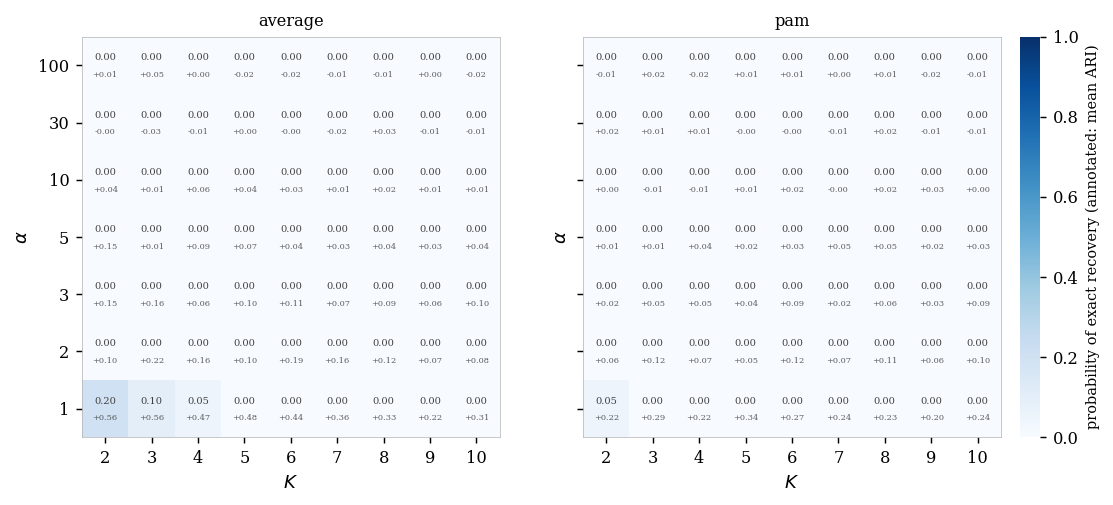

In [5]:
with plt.rc_context(PAPER_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0), sharey=True)
    for ax, algo in zip(axes, ALGOS):
        sub = hmm_cluster[hmm_cluster.algorithm == algo]
        im = heatmap(ax, grid(sub, "exact_recovery"), ALPHAS_PRESENT, KS, algo,
                     annot=grid(sub, "ari"))
    cb = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
    cb.set_label("probability of exact recovery (annotated: mean ARI)", fontsize=8)
    cb.outline.set_visible(False)
    save(fig, FIGURES, "recovery_hmm")
    plt.show()

## Selecting $K$

The threshold of Theorem 3.8 against the applied default, on HMM dissimilarities.

figure written to Figures\HMM\k_selection_hmm.pdf


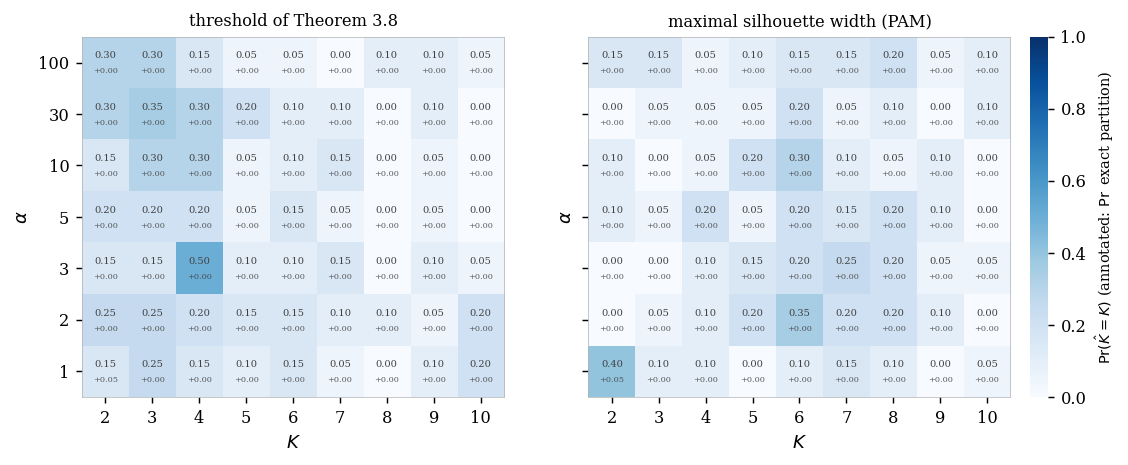

In [6]:
TITLES = {"threshold": "threshold of Theorem 3.8",
          "asw-pam": "maximal silhouette width (PAM)"}

with plt.rc_context(PAPER_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6), sharey=True)
    for ax, rule in zip(axes, RULES):
        sub = hmm_khat[hmm_khat.rule == rule]
        im = heatmap(ax, grid(sub, "k_correct"), ALPHAS_PRESENT, KS, TITLES[rule],
                     annot=grid(sub, "exact_recovery"))
    cb = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
    cb.set_label(r"$\Pr(\hat K = K)$ (annotated: $\Pr$ exact partition)", fontsize=8)
    cb.outline.set_visible(False)
    save(fig, FIGURES, "k_selection_hmm")
    plt.show()

## Recovery against the horizon

figure written to Figures\HMM\ari_path_single_hmm.pdf


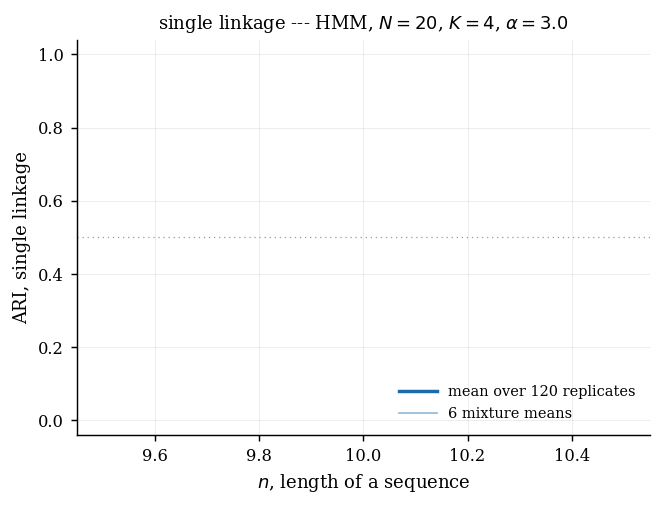

 n P(exact)       95% CI mean ARI
10     0.00 [0.00, 0.03]    0.012
figure written to Figures\HMM\ari_path_average_hmm.pdf


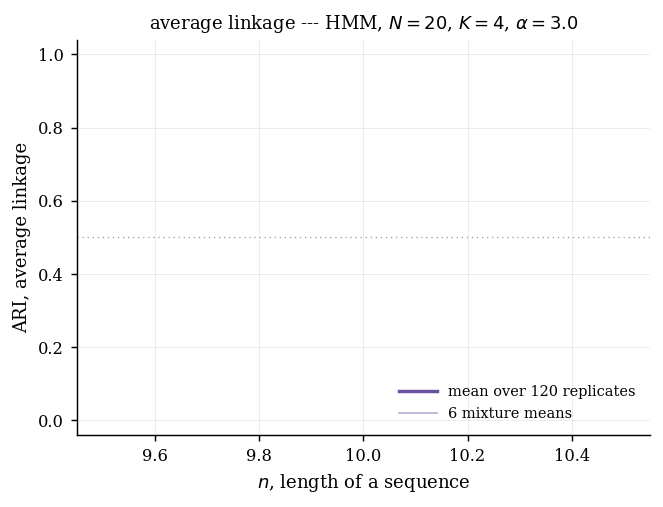

 n P(exact)       95% CI mean ARI
10     0.00 [0.00, 0.03]    0.101
figure written to Figures\HMM\ari_path_pam_hmm.pdf


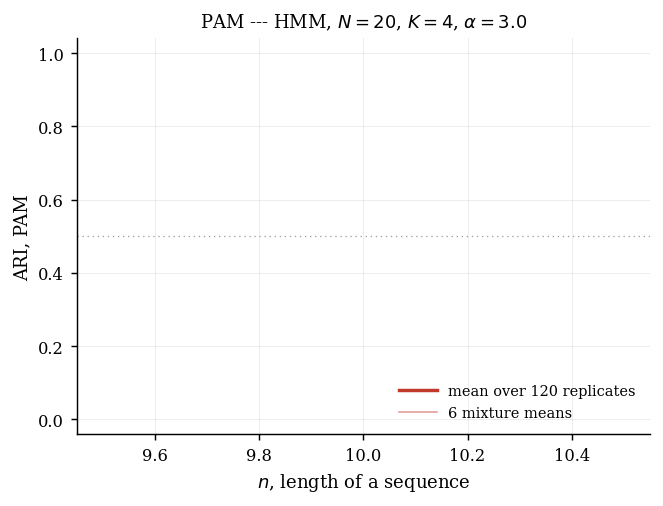

 n P(exact)       95% CI mean ARI
10     0.00 [0.00, 0.03]    0.070
PAM certified one-swap stationary in 118/120 runs; hit the swap cap 2 times


In [7]:
COL = {"single": "#1b6ca8", "average": "#6a51a3", "pam": "#c0392b"}
NAMES = {"single": "single linkage", "average": "average linkage", "pam": "PAM"}
HZ = np.sort(hmm_path.n.unique())


def curves(df, algorithm, value="ari"):
    """One row per dataset path, plus one mean path per mixture."""
    sub = df[df.algorithm == algorithm]
    reps = sub.pivot_table(index=["mixture_id", "dataset_id"], columns="n", values=value)
    means = sub.pivot_table(index="mixture_id", columns="n", values=value)
    return reps.reindex(columns=HZ).to_numpy(), means.reindex(columns=HZ).to_numpy()


def plot_ari_curve(algorithm, filename=None):
    reps, per_mixture = curves(hmm_path, algorithm)
    colour = COL[algorithm]
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.2, 4.0))
        ax.plot(HZ, reps.T, color=colour, lw=0.6, alpha=0.13)
        ax.plot(HZ, per_mixture.T, color=colour, lw=0.9, alpha=0.5)
        ax.plot(HZ, reps.mean(0), color=colour, lw=1.9,
                label=rf"mean over {reps.shape[0]} replicates")
        ax.plot([], [], color=colour, lw=0.9, alpha=0.5,
                label=rf"{per_mixture.shape[0]} mixture means")
        ax.set_xlabel(r"$n$, length of a sequence")
        ax.set_ylabel(f"ARI, {NAMES[algorithm]}")
        ax.set_ylim(-0.04, 1.04)
        ax.axhline(0.5, color="0.6", lw=0.7, ls=(0, (1, 3)), zorder=0)
        ax.set_title(rf"{NAMES[algorithm]} --- HMM, $N = {int(hmm_path.N.iloc[0])}$, "
                     rf"$K = {PATH_K}$, $\alpha = {PATH_ALPHA}$", fontsize=10)
        ax.legend(loc="lower right", handlelength=2.6, borderaxespad=0.6)
        fig.tight_layout()
        if filename is not None:
            save(fig, FIGURES, filename)
        plt.show()
    return fig


def exact_recovery_table(algorithm):
    """P(ARI = 1) at each horizon, with its Wilson interval."""
    sub = hmm_path[hmm_path.algorithm == algorithm]
    rows = []
    for n in HZ:
        at_n = sub[sub.n == n]
        s = at_n.exact_recovery
        lo, hi = wilson_interval(int(s.sum()), len(s), LEVEL)
        rows.append({"n": int(n), "P(exact)": f"{s.mean():.2f}",
                     "95% CI": f"[{lo:.2f}, {hi:.2f}]",
                     "mean ARI": f"{at_n.ari.mean():.3f}"})
    return pd.DataFrame(rows)


for algorithm in PATH_ALGOS:
    _ = plot_ari_curve(algorithm, filename=f"ari_path_{algorithm}_hmm")
    print(exact_recovery_table(algorithm).to_string(index=False))

certified = hmm_path[hmm_path.algorithm == "pam"]
print(f"PAM certified one-swap stationary in "
      f"{int(certified.pam_one_swap_certified.sum())}/{len(certified)} runs; "
      f"hit the swap cap {int(certified.pam_hit_cap.sum())} times")